In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import warnings
import pickle

warnings.filterwarnings('ignore')

# Reading bitcoin data and computing return values over different horizons as well as the class label for each horizon. Splitting the dataset

In [18]:

# Read the CSV file
df = pd.read_csv('BTC-2019min.csv')

# Convert the 'Date' column to datetime format
df['date'] = pd.to_datetime(df['date'])

# Filter the data between 4 March 2019 and 10 December 2019
start_date = pd.to_datetime('2019-03-01')
end_date = pd.to_datetime('2019-12-18')
filtered_data = df.loc[(df['date'] >= start_date) & (df['date'] <= end_date)]


filtered_data = filtered_data[['date','open','high','low','close']]

#inverse the rows,to have increasing date
filtered_data = filtered_data.iloc[::-1]

#drop the last row
filtered_data = filtered_data.drop(filtered_data.index[-1])


# Save the filtered data to a new CSV file
filtered_data.to_csv('bitcoin_minuntelyV2.csv', index=False)

bitcoin = filtered_data

In [19]:
bitcoin.describe()

,date,open,high,low,close
count,420480,420480.000000,420480.000000,420480.000000,420480.000000
mean,2019-07-24 23:59:30.000000512,8106.428355,8111.390975,8101.287972,8106.062021
min,2019-03-01 00:00:00,3671.440000,3671.440000,3670.000000,3671.440000
25%,2019-05-12 23:59:45,6879.982500,6883.335000,6876.340000,6879.947500
50%,2019-07-24 23:59:30,8241.955000,8246.955000,8237.495000,8241.550000
75%,2019-10-05 23:59:15,10049.122500,10055.000000,10041.752500,10047.952500
max,2019-12-17 23:59:00,13853.250000,13880.000000,13830.060000,13850.570000
std,NaN,2326.758237,2329.093398,2324.192854,2326.510893


In [20]:
bitcoin.head()

,date,open,high,low,close
440639,2019-03-01 00:00:00,3791.02,3792.85,3791.02,3791.02
440638,2019-03-01 00:01:00,3791.21,3792.72,3791.21,3792.72
440637,2019-03-01 00:02:00,3792.72,3793.43,3792.72,3793.43
440636,2019-03-01 00:03:00,3793.55,3793.55,3793.55,3793.55
440635,2019-03-01 00:04:00,3793.55,3793.55,3793.55,3793.55


In [21]:
bitcoin.tail()

,date,open,high,low,close
20164,2019-12-17 23:55:00,6618.84,6619.50,6607.11,6607.11
20163,2019-12-17 23:56:00,6611.26,6614.57,6606.10,6613.69
20162,2019-12-17 23:57:00,6619.22,6619.22,6610.04,6612.57
20161,2019-12-17 23:58:00,6610.86,6618.64,6608.39,6608.39
20160,2019-12-17 23:59:00,6610.23,6618.65,6610.23,6612.30


**In the following cell, the return values are calculated over different time horizons using closed price of bitcoin**

In [27]:

bitcoin = pd.read_csv('bitcoin_minuntely.csv')

bitcoin = bitcoin[['date','close']]

num_rows = bitcoin.shape[0]

end_day = pd.to_datetime('2019-12-11')

m = [1, 5, 15, 60 , 10080]
returns_mean = []
allreturns = []

for horizon in m:

  returns = list()

  i = 0

  while(pd.to_datetime(bitcoin['date'].iloc[ i ]) < end_day ):

    returns.append( (bitcoin['close'][ i ] / bitcoin['close'].iloc[i - horizon]) - 1 )
    i+=1
  
  allreturns.append(returns)

np.shape(allreturns)


(5, 406080)

**In this cell, data is split into train, val, and test sets as well as the class label for each timestep sample is calculated**


In [28]:
bitcoin = bitcoin[ bitcoin['date'] < '2019-12-11']

allreturns =  np.array(allreturns)

num_timestamps = len(bitcoin)

index1 = int(num_timestamps * 5/9)

index2 = int (num_timestamps * 6/9)

bitcoin_train = bitcoin[: index1]

bitcoin_val = bitcoin[index1 : index2]

bitcoin_test = bitcoin[index2 : ]

#computing the median of different return horizons for the training set
median_train_one = np.median(allreturns[0 , : index1])
median_train_five = np.median(allreturns[1 , : index1])
median_train_fifteen = np.median(allreturns[2 , : index1])
median_train_sixty = np.median(allreturns[3 , : index1])

#Training set
bitcoin_train.loc[: , '1m return'] = allreturns[0 , : index1]
bitcoin_train.loc[: , '1m class'] = np.array(allreturns[0 , : index1] < median_train_one).astype(int)

bitcoin_train.loc[: , '5m return'] = allreturns[1 , : index1]
bitcoin_train.loc[: , '5m class'] = np.array(allreturns[1 , : index1] < median_train_five).astype(int)

bitcoin_train.loc[: , '15m return'] = allreturns[2 , : index1]
bitcoin_train.loc[: , '15m class'] = np.array(allreturns[2 , : index1] < median_train_fifteen).astype(int)

bitcoin_train.loc[: , '60m return'] = allreturns[3 , : index1]
bitcoin_train.loc[: , '60m class'] = np.array(allreturns[3 , : index1] < median_train_sixty).astype(int)

bitcoin_train.loc[: , '1week return'] = allreturns[4 , : index1]

#Validation set
bitcoin_val.loc[: , '1m return'] = allreturns[0 , index1: index2]
bitcoin_val.loc[: , '1m class'] = np.array(allreturns[0 , index1 :index2 ] < median_train_one).astype(int)

bitcoin_val.loc[: , '5m return'] = allreturns[1 , index1 :index2]
bitcoin_val.loc[: , '5m class'] = np.array(allreturns[1 , index1 :index2] < median_train_five).astype(int)

bitcoin_val.loc[: , '15m return'] = allreturns[2 , index1 :index2]
bitcoin_val.loc[: , '15m class'] = np.array(allreturns[2 , index1 :index2] < median_train_fifteen).astype(int)

bitcoin_val.loc[: , '60m return'] = allreturns[3 , index1 :index2]
bitcoin_val.loc[: , '60m class'] = np.array(allreturns[3 , index1 :index2] < median_train_sixty).astype(int)

bitcoin_val.loc[: , '1week return'] = allreturns[4 , index1 :index2]


#test set 
bitcoin_test.loc[: , '1m return'] = allreturns[0 , index2 :]
bitcoin_test.loc[: , '1m class'] = np.array(allreturns[0 , index2 : ] < median_train_one).astype(int)

bitcoin_test.loc[: , '5m return'] = allreturns[1 , index2 :]
bitcoin_test.loc[: , '5m class'] = np.array(allreturns[1 , index2 :] < median_train_five).astype(int)

bitcoin_test.loc[: , '15m return'] = allreturns[2 , index2 :]
bitcoin_test.loc[: , '15m class'] = np.array(allreturns[2 , index2 :] < median_train_fifteen).astype(int)

bitcoin_test.loc[: , '60m return'] = allreturns[3 , index2 :]
bitcoin_test.loc[: , '60m class'] = np.array(allreturns[3 , index2 :] < median_train_sixty).astype(int)

bitcoin_test.loc[: , '1week return'] = allreturns[4 , index2 :]

bitcoin_train.to_csv('bitcoin_train_rawV2.csv')  
bitcoin_val.to_csv('bitcoin_val_rawV2.csv') 
bitcoin_test.to_csv('bitcoin_test_rawV2.csv')



In [29]:
#this includes all the return values for different horizons and the class labels for them 
bitcoin_train.describe()


,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
count,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000
mean,7488.072500,0.000004,0.455421,0.000019,0.500000,0.000057,0.500000,0.000228,0.500000,0.033348
std,2724.039258,0.001548,0.498010,0.003389,0.500001,0.005834,0.500001,0.011483,0.500001,0.155233
min,3671.440000,-0.427302,0.000000,-0.426992,0.000000,-0.427466,0.000000,-0.426723,0.000000,-0.492352
25%,5132.655000,-0.000439,0.000000,-0.000885,0.000000,-0.001412,0.000000,-0.002438,0.000000,-0.024573
50%,7840.990000,0.000000,0.000000,0.000024,0.500000,0.000086,0.500000,0.000265,0.500000,0.030461
75%,9847.960000,0.000464,1.000000,0.000961,1.000000,0.001604,1.000000,0.003133,1.000000,0.115483
max,13850.570000,0.105122,1.000000,0.080455,1.000000,0.163627,1.000000,0.214031,1.000000,0.517274


In [30]:
bitcoin_train.head()

,date,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
0,2019-03-04 00:00:00,3786.85,-0.427302,1,-0.426852,1,-0.426730,1,-0.425144,1,-0.475719
1,2019-03-04 00:01:00,3789.70,0.000753,0,-0.426992,1,-0.426653,1,-0.424712,1,-0.474746
2,2019-03-04 00:02:00,3790.65,0.000251,0,-0.426751,1,-0.426961,1,-0.424925,1,-0.475167
3,2019-03-04 00:03:00,3792.87,0.000586,0,-0.426052,1,-0.426625,1,-0.423882,1,-0.475274
4,2019-03-04 00:04:00,3793.04,0.000045,0,-0.426366,1,-0.426640,1,-0.424153,1,-0.475469


In [31]:
bitcoin_train.tail()

,date,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
225595,2019-08-07 15:55:00,11609.22,-0.004070,1,-0.006433,1,-0.007488,1,-0.039129,1,0.154820
225596,2019-08-07 15:56:00,11622.93,0.001181,0,-0.001918,1,-0.006324,1,-0.037886,1,0.156687
225597,2019-08-07 15:57:00,11652.59,0.002552,0,-0.000360,1,-0.002200,1,-0.035653,1,0.159085
225598,2019-08-07 15:58:00,11655.41,0.000242,0,-0.000520,1,-0.002309,1,-0.034170,1,0.159365
225599,2019-08-07 15:59:00,11653.35,-0.000177,1,-0.000284,1,-0.001854,1,-0.033785,1,0.159212


# standardizing the dataset

Loading and splitting the twitter features for training the model:


In [32]:

bitcoin_train = pd.read_csv('bitcoin_train_rawV2.csv')  
bitcoin_val = pd.read_csv('bitcoin_val_rawV2.csv') 
bitcoin_test = pd.read_csv('bitcoin_test_rawV2.csv')

tweets_features_all = pd.read_csv('The features of twitter.csv')
tweets_features_all.drop(tweets_features_all.columns[0],axis=1, inplace=True)


index1 = bitcoin_train.shape[0]
index2 = index1 + bitcoin_val.shape[0]

sentiment_train = tweets_features_all[:index1]
sentiment_val = tweets_features_all[index1 : index2]
sentiment_test = tweets_features_all[index2 :]


sentiment_train.shape[0] == bitcoin_train.shape[0] , sentiment_val.shape[0] == bitcoin_val.shape[0] , sentiment_test.shape[0]== bitcoin_test.shape[0]

(True, True, True)

Following we standardize the bitcoin return features.

In [33]:

def standardization( dataframe1, dataframe2, dataframe3 ,startcolumns , step ):

  for i in range (startcolumns , len(dataframe1.columns) ,step):
    
    retrn_data = dataframe1.iloc[:, i].values.reshape(-1, 1)

    scaler = StandardScaler()
    retrn_data_standardized = scaler.fit_transform(retrn_data)

    dataframe1[dataframe1.columns[i]] = retrn_data_standardized.flatten()


##########validation data
    retrn_data = dataframe2.iloc[:, i].values.reshape(-1, 1)

    retrn_data_standardized = scaler.transform(retrn_data)

    dataframe2[dataframe2.columns[i]] = retrn_data_standardized.flatten()

##########test data

    retrn_data = dataframe3.iloc[:, i].values.reshape(-1, 1)

    retrn_data_standardized = scaler.transform(retrn_data)

    dataframe3[dataframe3.columns[i]] = retrn_data_standardized.flatten()




  return dataframe1 , dataframe2, dataframe3

bitcoin_train , bitcoin_val , bitcoin_test = standardization(bitcoin_train , bitcoin_val , bitcoin_test ,3 ,2 )



In [34]:
bitcoin_train.describe()

,Unnamed: 0,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
count,225600.000000,225600.000000,2.256000e+05,225600.000000,2.256000e+05,225600.000000,2.256000e+05,225600.000000,2.256000e+05,225600.000000,2.256000e+05
mean,112799.500000,7488.072500,7.307000e-18,0.455421,-7.432983e-18,0.500000,3.905465e-18,0.500000,-3.527517e-18,0.500000,-4.031448e-17
std,65125.254702,2724.039258,1.000002e+00,0.498010,1.000002e+00,0.500001,1.000002e+00,0.500001,1.000002e+00,0.500001,1.000002e+00
min,0.000000,3671.440000,-2.760026e+02,0.000000,-1.260125e+02,0.000000,-7.328393e+01,0.000000,-3.717962e+01,0.000000,-3.386533e+00
25%,56399.750000,5132.655000,-2.862924e-01,0.000000,-2.667524e-01,0.000000,-2.518070e-01,0.000000,-2.321944e-01,0.000000,-3.731216e-01
50%,112799.500000,7840.990000,-2.506817e-03,0.000000,1.480773e-03,0.500000,4.956302e-03,0.500000,3.219835e-03,0.500000,-1.859869e-02
75%,169199.250000,9847.960000,2.972829e-01,1.000000,2.778953e-01,1.000000,2.651350e-01,1.000000,2.529801e-01,1.000000,5.291117e-01
max,225599.000000,13850.570000,6.789691e+01,1.000000,2.373680e+01,1.000000,2.803836e+01,1.000000,1.861830e+01,1.000000,3.117431e+00


In [35]:
bitcoin_val.describe()

,Unnamed: 0,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
count,45120.00000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000,45120.000000
mean,248159.50000,10465.962560,-0.003694,0.474158,-0.008435,0.516534,-0.014819,0.526662,-0.030576,0.537345,-0.276813
std,13025.16641,645.280724,0.649433,0.499337,0.603089,0.499732,0.588721,0.499294,0.593972,0.498609,0.529757
min,225600.00000,9333.690000,-12.433787,0.000000,-13.206157,0.000000,-9.465401,0.000000,-5.748997,0.000000,-1.476600
25%,236879.75000,10082.020000,-0.325057,0.000000,-0.286065,0.000000,-0.270083,0.000000,-0.256293,0.000000,-0.605974
50%,248159.50000,10362.545000,-0.002507,0.000000,-0.008106,1.000000,-0.018584,1.000000,-0.027055,1.000000,-0.404956
75%,259439.25000,10718.792500,0.309470,1.000000,0.265463,1.000000,0.240366,1.000000,0.209111,1.000000,0.064560
max,270719.00000,12050.880000,9.559651,1.000000,11.220408,1.000000,8.361646,1.000000,5.008457,1.000000,1.100230


In [36]:
bitcoin_test.describe()

,Unnamed: 0,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
count,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000,135360.000000
mean,338399.500000,8561.705914,-0.003947,0.468262,-0.009082,0.518839,-0.015891,0.529477,-0.032170,0.547592,-0.349240
std,39075.210556,969.418938,0.665236,0.498994,0.610047,0.499647,0.590311,0.499132,0.598359,0.497732,0.543833
min,270720.000000,6525.420000,-13.630797,0.000000,-14.943596,0.000000,-14.467192,0.000000,-12.233818,0.000000,-1.692872
25%,304559.750000,7927.230000,-0.300713,0.000000,-0.248102,0.000000,-0.232934,0.000000,-0.230998,0.000000,-0.594475
50%,338399.500000,8334.445000,-0.002507,0.000000,-0.006719,1.000000,-0.016271,1.000000,-0.031045,1.000000,-0.331629
75%,372239.250000,9268.817500,0.283056,1.000000,0.228366,1.000000,0.201070,1.000000,0.167918,1.000000,-0.124599
max,406079.000000,10593.400000,16.374455,1.000000,20.949044,1.000000,16.619500,1.000000,9.905334,1.000000,1.710927


Following we standardize the tweets' features.

In [37]:
sentiment_train, sentiment_val , sentiment_test = standardization(sentiment_train, sentiment_val ,sentiment_test, 1, 1)

In [38]:
sentiment_train.describe()

,num_tweets,sum_score,Weighted_Sentiment_Score
count,2.256000e+05,2.256000e+05,2.256000e+05
mean,1.259828e-17,2.217296e-17,-1.562186e-17
std,1.000002e+00,1.000002e+00,1.000002e+00
min,-4.592980e-01,-1.202260e+01,-1.808948e+01
25%,-4.592980e-01,2.885726e-02,1.857049e-03
50%,-4.592980e-01,2.885726e-02,1.857049e-03
75%,-4.592980e-01,2.885726e-02,1.857049e-03
max,2.694424e+01,1.449061e+01,2.971687e+01


In [39]:
sentiment_test.describe()

,num_tweets,sum_score,Weighted_Sentiment_Score
count,135360.000000,135360.000000,135360.000000
mean,-0.127972,-0.006809,-0.007871
std,0.785428,0.829729,0.833127
min,-0.459298,-12.022600,-16.823082
25%,-0.459298,0.028857,0.001857
50%,-0.459298,0.028857,0.001857
75%,-0.459298,0.028857,0.001857
max,15.660432,17.503470,30.621436


In [40]:
sentiment_val.describe()

,num_tweets,sum_score,Weighted_Sentiment_Score
count,45120.000000,45120.000000,45120.000000
mean,-0.138297,0.004738,-0.010902
std,0.768307,0.813455,0.793814
min,-0.459298,-8.407163,-17.411050
25%,-0.459298,0.028857,0.001857
50%,-0.459298,0.028857,0.001857
75%,-0.459298,0.028857,0.001857
max,14.048459,8.464877,18.907298


# Generate dataset suitable for training RNN models. 

In [41]:
def data_generator_for_model(df , columnnames):

  window_size = 120
  slide_step = 1

  classes = df[columnnames[-1]]

  df = df[columnnames[:-1]]
  
  # print(df.shape)
  # print(classes.shape)
  
  X = np.array([df[i:i+window_size] for i in range(0, len(df)-window_size, slide_step)])

  Y = np.array([classes[i] for i in range(120,len(classes))])
  
  return X , Y


 

Following the data is ready to feed to the model for training, validating, and testing :

In [42]:
dataset_train = pd.concat([sentiment_train ,  bitcoin_train.drop(bitcoin_train.columns[0:2], axis = 1)], axis = 1 )

columns_name = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '60m return' , '1week return', '60m class']

X_train , Y_train = data_generator_for_model(dataset_train , columns_name)

X_train.shape , Y_train.shape

((225480, 120, 5), (225480,))

In [43]:
dataset_train.tail()

,date,num_tweets,sum_score,Weighted_Sentiment_Score,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
225595,2019-08-07 15:55:00+00:00,-0.459298,0.028857,0.001857,11609.22,-2.631229,1,-1.904161,1,-1.293448,1,-3.427336,1,0.782518
225596,2019-08-07 15:56:00+00:00,-0.459298,0.028857,0.001857,11622.93,0.760289,0,-0.571769,1,-1.093840,1,-3.319020,1,0.794542
225597,2019-08-07 15:57:00+00:00,1.152675,0.028857,0.001857,11652.59,1.645768,0,-0.111976,1,-0.386909,1,-3.124614,1,0.809990
225598,2019-08-07 15:58:00+00:00,-0.459298,0.028857,0.001857,11655.41,0.153808,0,-0.159002,1,-0.405558,1,-2.995499,1,0.811797
225599,2019-08-07 15:59:00+00:00,1.152675,-3.586580,-3.525953,11653.35,-0.116667,1,-0.089446,1,-0.327699,1,-2.961977,1,0.810811


In [44]:
bitcoin_val.reset_index(drop=True, inplace=True)
sentiment_val.reset_index(drop=True, inplace=True)


dataset_val = pd.concat([sentiment_val , bitcoin_val.drop(bitcoin_val.columns[0:2]  , axis = 1)] , axis = 1 )

columns_name = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '60m return' , '1week return', '60m class']

X_val , Y_val = data_generator_for_model(dataset_val , columns_name)

X_val.shape, Y_val.shape

((45000, 120, 5), (45000,))

In [45]:
dataset_val.head()

,date,num_tweets,sum_score,Weighted_Sentiment_Score,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
0,2019-08-07 16:00:00+00:00,1.152675,0.028857,0.001857,11653.94,0.030195,0,1.131124,0,-0.328708,1,-3.209861,1,0.788785
1,2019-08-07 16:01:00+00:00,-0.459298,0.028857,0.001857,11679.32,1.404166,0,1.426082,0,-0.036389,1,-2.866450,1,0.802093
2,2019-08-07 16:02:00+00:00,2.764648,-1.778861,-0.812253,11691.99,0.698195,0,0.992163,0,0.207281,0,-2.774511,1,0.815444
3,2019-08-07 16:03:00+00:00,-0.459298,0.028857,0.001857,11675.26,-0.926740,1,0.496934,0,0.000597,1,-2.942084,1,0.814670
4,2019-08-07 16:04:00+00:00,-0.459298,0.028857,0.001857,11671.20,-0.227119,1,0.446376,0,-0.139563,1,-1.570212,1,0.830234


In [46]:
bitcoin_test.reset_index(drop=True, inplace=True)
sentiment_test.reset_index(drop=True, inplace=True)


dataset_test = pd.concat([sentiment_test , bitcoin_test.drop(bitcoin_test.columns[0:2]  , axis = 1)] , axis = 1 )

columns_name = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '60m return' , '1week return', '60m class']

X_test , Y_test = data_generator_for_model(dataset_test , columns_name)

X_test.shape, Y_test.shape

((135240, 120, 5), (135240,))

In [47]:
dataset_test.head()

,date,num_tweets,sum_score,Weighted_Sentiment_Score,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
0,2019-09-08 00:00:00+00:00,1.152675,-4.791726,-5.787369,10486.56,0.131181,0,-0.183113,1,-0.169218,1,-0.102848,1,0.384857
1,2019-09-08 00:01:00+00:00,-0.459298,0.028857,0.001857,10510.33,1.461591,0,0.513856,0,0.173847,0,0.087957,0,0.399406
2,2019-09-08 00:02:00+00:00,-0.459298,0.028857,0.001857,10516.10,0.352089,0,0.823101,0,0.436163,0,0.142222,0,0.397634
3,2019-09-08 00:03:00+00:00,-0.459298,0.028857,0.001857,10511.39,-0.291801,1,0.716510,0,0.088400,0,0.106885,0,0.395260
4,2019-09-08 00:04:00+00:00,-0.459298,0.028857,0.001857,10502.73,-0.534654,1,0.510567,0,0.118878,0,0.035037,0,0.388320


following we save the variables of X and Y for train, val, and test as a pickle object so later they can be loaded for training the model

In [48]:

filepath = ''

with open(filepath+'X_trainV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(X_train, file)
  
with open(filepath+'Y_trainV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(Y_train, file)
  
with open(filepath+'X_valV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(X_val, file)
  
with open(filepath+'Y_valV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(Y_val, file)
  
with open(filepath+'X_testV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(X_test, file)
  
with open(filepath+'Y_testV3.pickle', 'wb') as file:
    # Serialize the object and write to file
    pickle.dump(Y_test, file)
  


So far, the data regarding 60 minute retursn were processed and saved to file. In the following the data ragarding other time horizons will be generated for models.

In [ ]:
#write 1m instead of 60min

columns_name_5 = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '5m return' , '1week return', '5m class']
columns_name_15 = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '15m return' , '1week return', '15m class']
columns_name_60 = ['num_tweets', 'sum_score', 'Weighted_Sentiment_Score' , '60m return' , '1week return', '60m class']

def save_pickle (x, filename):

  with open(filename, 'wb') as file:
    pickle.dump(x, file)


data_dict = {'train' : dataset_train , 'val' : dataset_val , 'test' : dataset_test}


def genet_save(namecolumns , stringreturn , filepath):

  for key in data_dict:
    
    X , Y = data_generator_for_model(data_dict[key], namecolumns)
    print(Y)
    save_pickle(X , filepath+'X' + '_' + key + '_' + stringreturn + '.pickle')
    save_pickle(Y , filepath+'Y' + '_' + key + '_' + stringreturn + '.pickle')

genet_save(columns_name_5 , '5min', '/content/drive/MyDrive/Dataset_with_memory /5min/')
genet_save(columns_name_15 , '15min', '/content/drive/MyDrive/Dataset_with_memory /15min/')
genet_save(columns_name_60 , '60min', '/content/drive/MyDrive/Dataset_with_memory /60min/')











  

[1 1 0 ... 0 0 0]
[0 0 1 ... 0 0 0]
[0 0 0 ... 1 0 0]
[1 1 1 ... 0 0 0]
[1 1 1 ... 0 0 0]
[0 0 1 ... 0 0 0]
[1 1 1 ... 1 1 1]
[1 1 1 ... 0 0 0]
[1 1 1 ... 0 0 0]


# Inspecting the correlation between different timeseries features 

**Inspecting the Correlation between different features**

In [49]:
bitcoin_train = pd.read_csv('bitcoin_train_rawV2.csv')
bitcoin_train.head()

,Unnamed: 0,date,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
0,0,2019-03-04 00:00:00,3786.85,-0.427302,1,-0.426852,1,-0.426730,1,-0.425144,1,-0.475719
1,1,2019-03-04 00:01:00,3789.70,0.000753,0,-0.426992,1,-0.426653,1,-0.424712,1,-0.474746
2,2,2019-03-04 00:02:00,3790.65,0.000251,0,-0.426751,1,-0.426961,1,-0.424925,1,-0.475167
3,3,2019-03-04 00:03:00,3792.87,0.000586,0,-0.426052,1,-0.426625,1,-0.423882,1,-0.475274
4,4,2019-03-04 00:04:00,3793.04,0.000045,0,-0.426366,1,-0.426640,1,-0.424153,1,-0.475469


In [50]:
bitcoin_train.describe()

,Unnamed: 0,close,1m return,1m class,5m return,5m class,15m return,15m class,60m return,60m class,1week return
count,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000,225600.000000
mean,112799.500000,7488.072500,0.000004,0.455421,0.000019,0.500000,0.000057,0.500000,0.000228,0.500000,0.033348
std,65125.254702,2724.039258,0.001548,0.498010,0.003389,0.500001,0.005834,0.500001,0.011483,0.500001,0.155233
min,0.000000,3671.440000,-0.427302,0.000000,-0.426992,0.000000,-0.427466,0.000000,-0.426723,0.000000,-0.492352
25%,56399.750000,5132.655000,-0.000439,0.000000,-0.000885,0.000000,-0.001412,0.000000,-0.002438,0.000000,-0.024573
50%,112799.500000,7840.990000,0.000000,0.000000,0.000024,0.500000,0.000086,0.500000,0.000265,0.500000,0.030461
75%,169199.250000,9847.960000,0.000464,1.000000,0.000961,1.000000,0.001604,1.000000,0.003133,1.000000,0.115483
max,225599.000000,13850.570000,0.105122,1.000000,0.080455,1.000000,0.163627,1.000000,0.214031,1.000000,0.517274


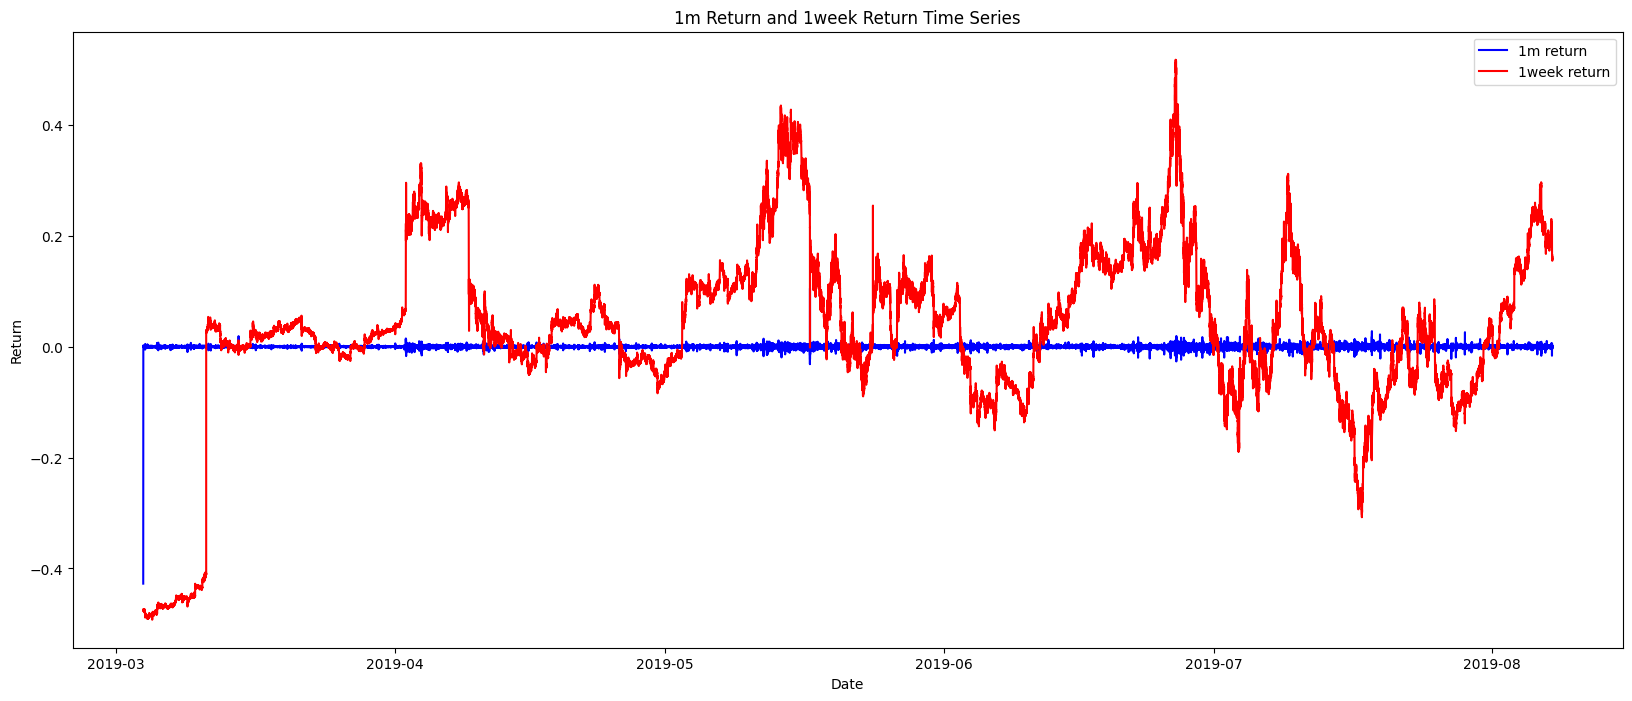

In [51]:
import matplotlib.pyplot as plt

# Convert the 'date' column to datetime format if it's not already
bitcoin_train['date'] = pd.to_datetime(bitcoin_train['date'])

plt.figure(figsize=(20, 8))
plt.plot(bitcoin_train['date'], bitcoin_train['1m return'], label='1m return', color='blue')
plt.plot(bitcoin_train['date'], bitcoin_train['1week return'], label='1week return', color='red')

plt.xlabel('Date')
plt.ylabel('Return')
plt.title('1m Return and 1week Return Time Series')
plt.legend()
plt.show()

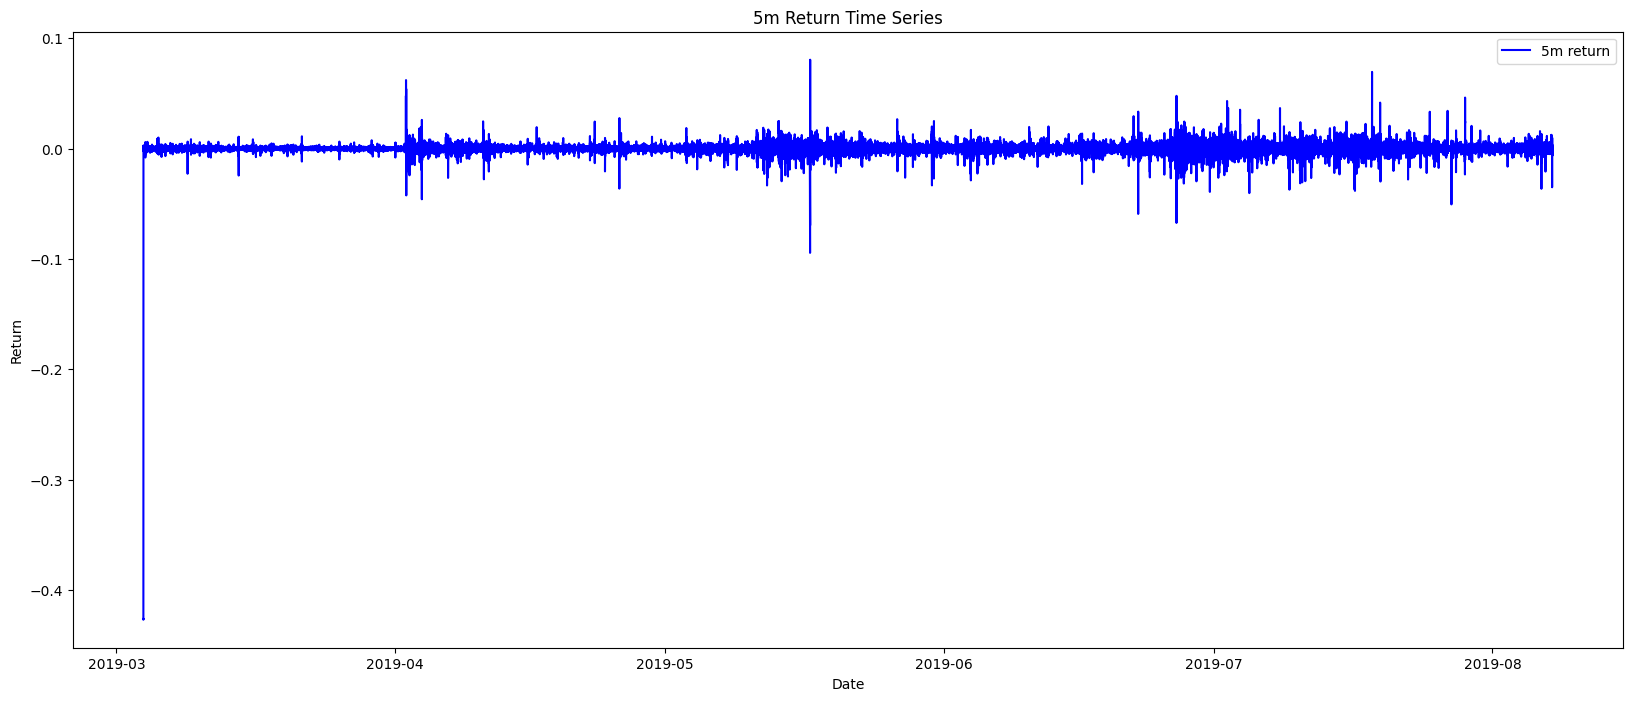

In [52]:
#plot other returns
plt.figure(figsize=(20, 8))
plt.plot(bitcoin_train['date'], bitcoin_train['5m return'], label='5m return', color='blue')
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('5m Return Time Series')
plt.legend()
plt.show()


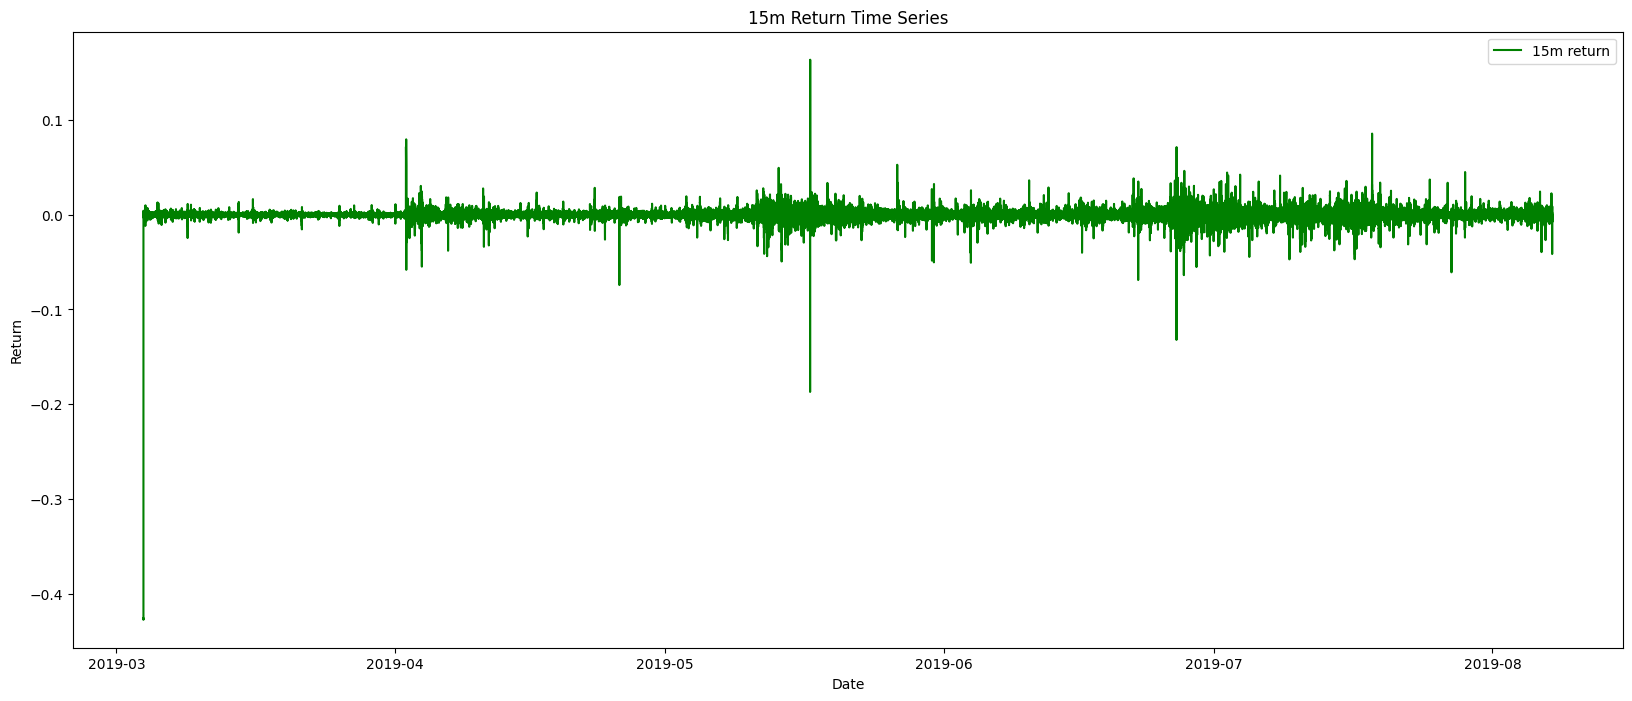

In [53]:
#plot other returns
plt.figure(figsize=(20, 8))
plt.plot(bitcoin_train['date'], bitcoin_train['15m return'], label='15m return', color='green')
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('15m Return Time Series')
plt.legend()
plt.show()

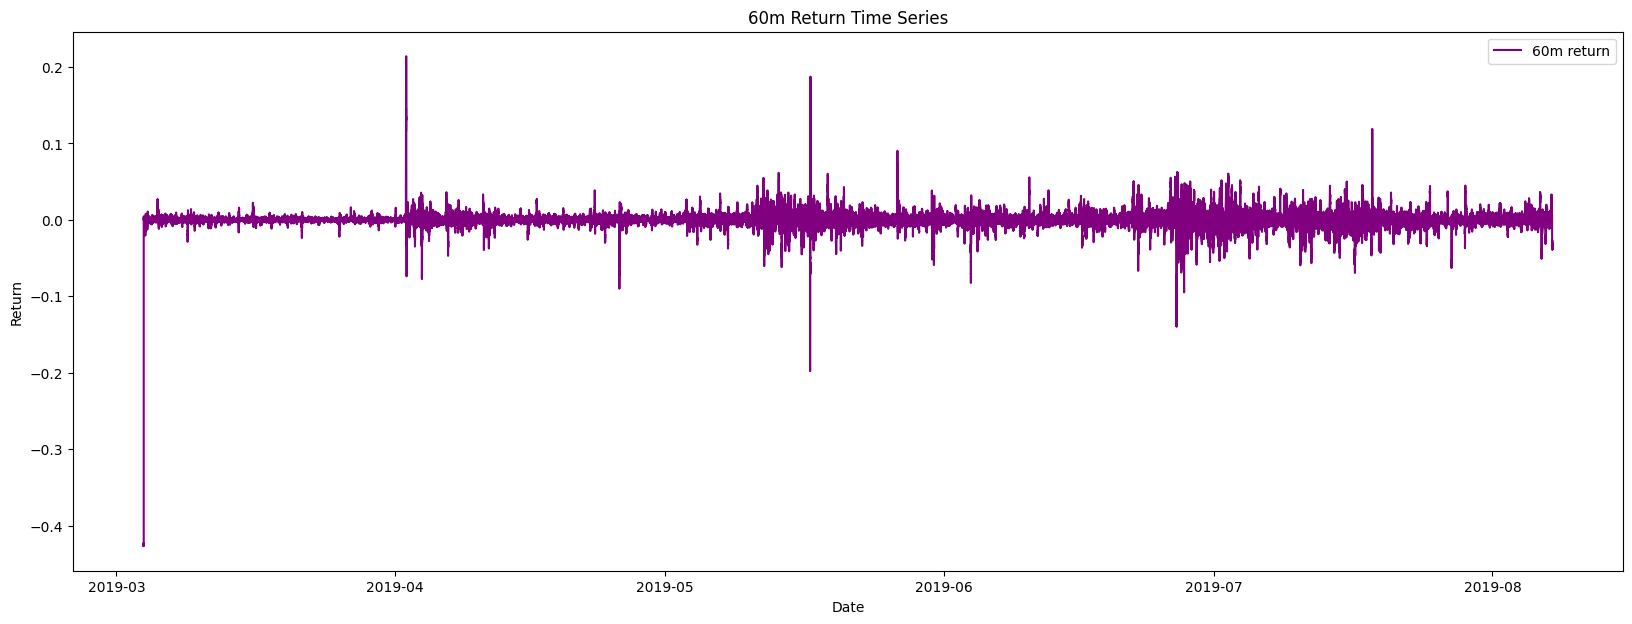

In [54]:
#plot other returns
plt.figure(figsize=(20, 7))
plt.plot(bitcoin_train['date'], bitcoin_train['60m return'], label='60m return', color='purple')
plt.xlabel('Date')
plt.ylabel('Return')
plt.title('60m Return Time Series')
plt.legend()
plt.show()

In [55]:
# Compute different types of correlation between the two features "60m return" and "1week return" 

correlation = bitcoin_train['60m return'].corr(bitcoin_train['1week return'], method='pearson')
print(f"\nPearson correlation between '60m return' and '1week return': {correlation}")

correlation = bitcoin_train['60m return'].corr(bitcoin_train['1week return'], method='spearman')
print(f"\nSpearman correlation between '60m return' and '1week return': {correlation}")

correlation = bitcoin_train['60m return'].corr(bitcoin_train['1week return'], method='kendall')
print(f"\nKendall Tau correlation between '60m return' and '1week return': {correlation}")


Pearson correlation between '60m return' and '1week return': 0.08256468732570756

Spearman correlation between '60m return' and '1week return': 0.08157258923249189

Kendall Tau correlation between '60m return' and '1week return': 0.05678550202668119


In [56]:
from scipy.stats import pointbiserialr



df = bitcoin_train.copy()

# Compute Point-Biserial Correlation for '60m return' and '60m class'
corr_60m_return, p_value_60m_return = pointbiserialr(df['60m return'], df['60m class'])

# Compute Point-Biserial Correlation for '1week return' and '60m class'
corr_1week_return, p_value_1week_return = pointbiserialr(df['1week return'], df['60m class'])

# Print the results nicely
print(f"Point-Biserial Correlation between '60m return' and '60m class': {corr_60m_return:.4f}, p-value: {p_value_60m_return:.4f}")
print(f"Point-Biserial Correlation between '1week return' and '60m class': {corr_1week_return:.4f}, p-value: {p_value_1week_return:.4f}")

Point-Biserial Correlation between '60m return' and '60m class': -0.4552, p-value: 0.0000
Point-Biserial Correlation between '1week return' and '60m class': -0.0498, p-value: 0.0000


In [57]:
import math

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

# select the style from fivethityeight website
plt.style.use('fivethirtyeight') 
mpl.rcParams['lines.linewidth'] = 2

# predefined figsize
figsize=(12,12)

import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

%config InlineBackend.figure_format = 'png' #set 'png' here when working on notebook
%matplotlib inline

In [62]:
bitcoin_train = pd.read_csv('bitcoin_train_rawV2.csv')  

timeseries = bitcoin_train[['60m return', '1week return', '60m class']]
#add the sentiment features also to the timeseries 
timeseries = pd.concat([sentiment_train , timeseries], axis=1)

#class_timeseries = bitcoin_train[['60m class']]
timeseries.head()

,date,num_tweets,sum_score,Weighted_Sentiment_Score,60m return,1week return,60m class
0,2019-03-04 00:00:00,-0.459298,0.028857,0.001857,-0.425144,-0.475719,1
1,2019-03-04 00:01:00,-0.459298,0.028857,0.001857,-0.424712,-0.474746,1
2,2019-03-04 00:02:00,-0.459298,0.028857,0.001857,-0.424925,-0.475167,1
3,2019-03-04 00:03:00+00:00,1.152675,1.234003,1.177794,-0.423882,-0.475274,1
4,2019-03-04 00:04:00+00:00,-0.459298,0.028857,0.001857,-0.424153,-0.475469,1


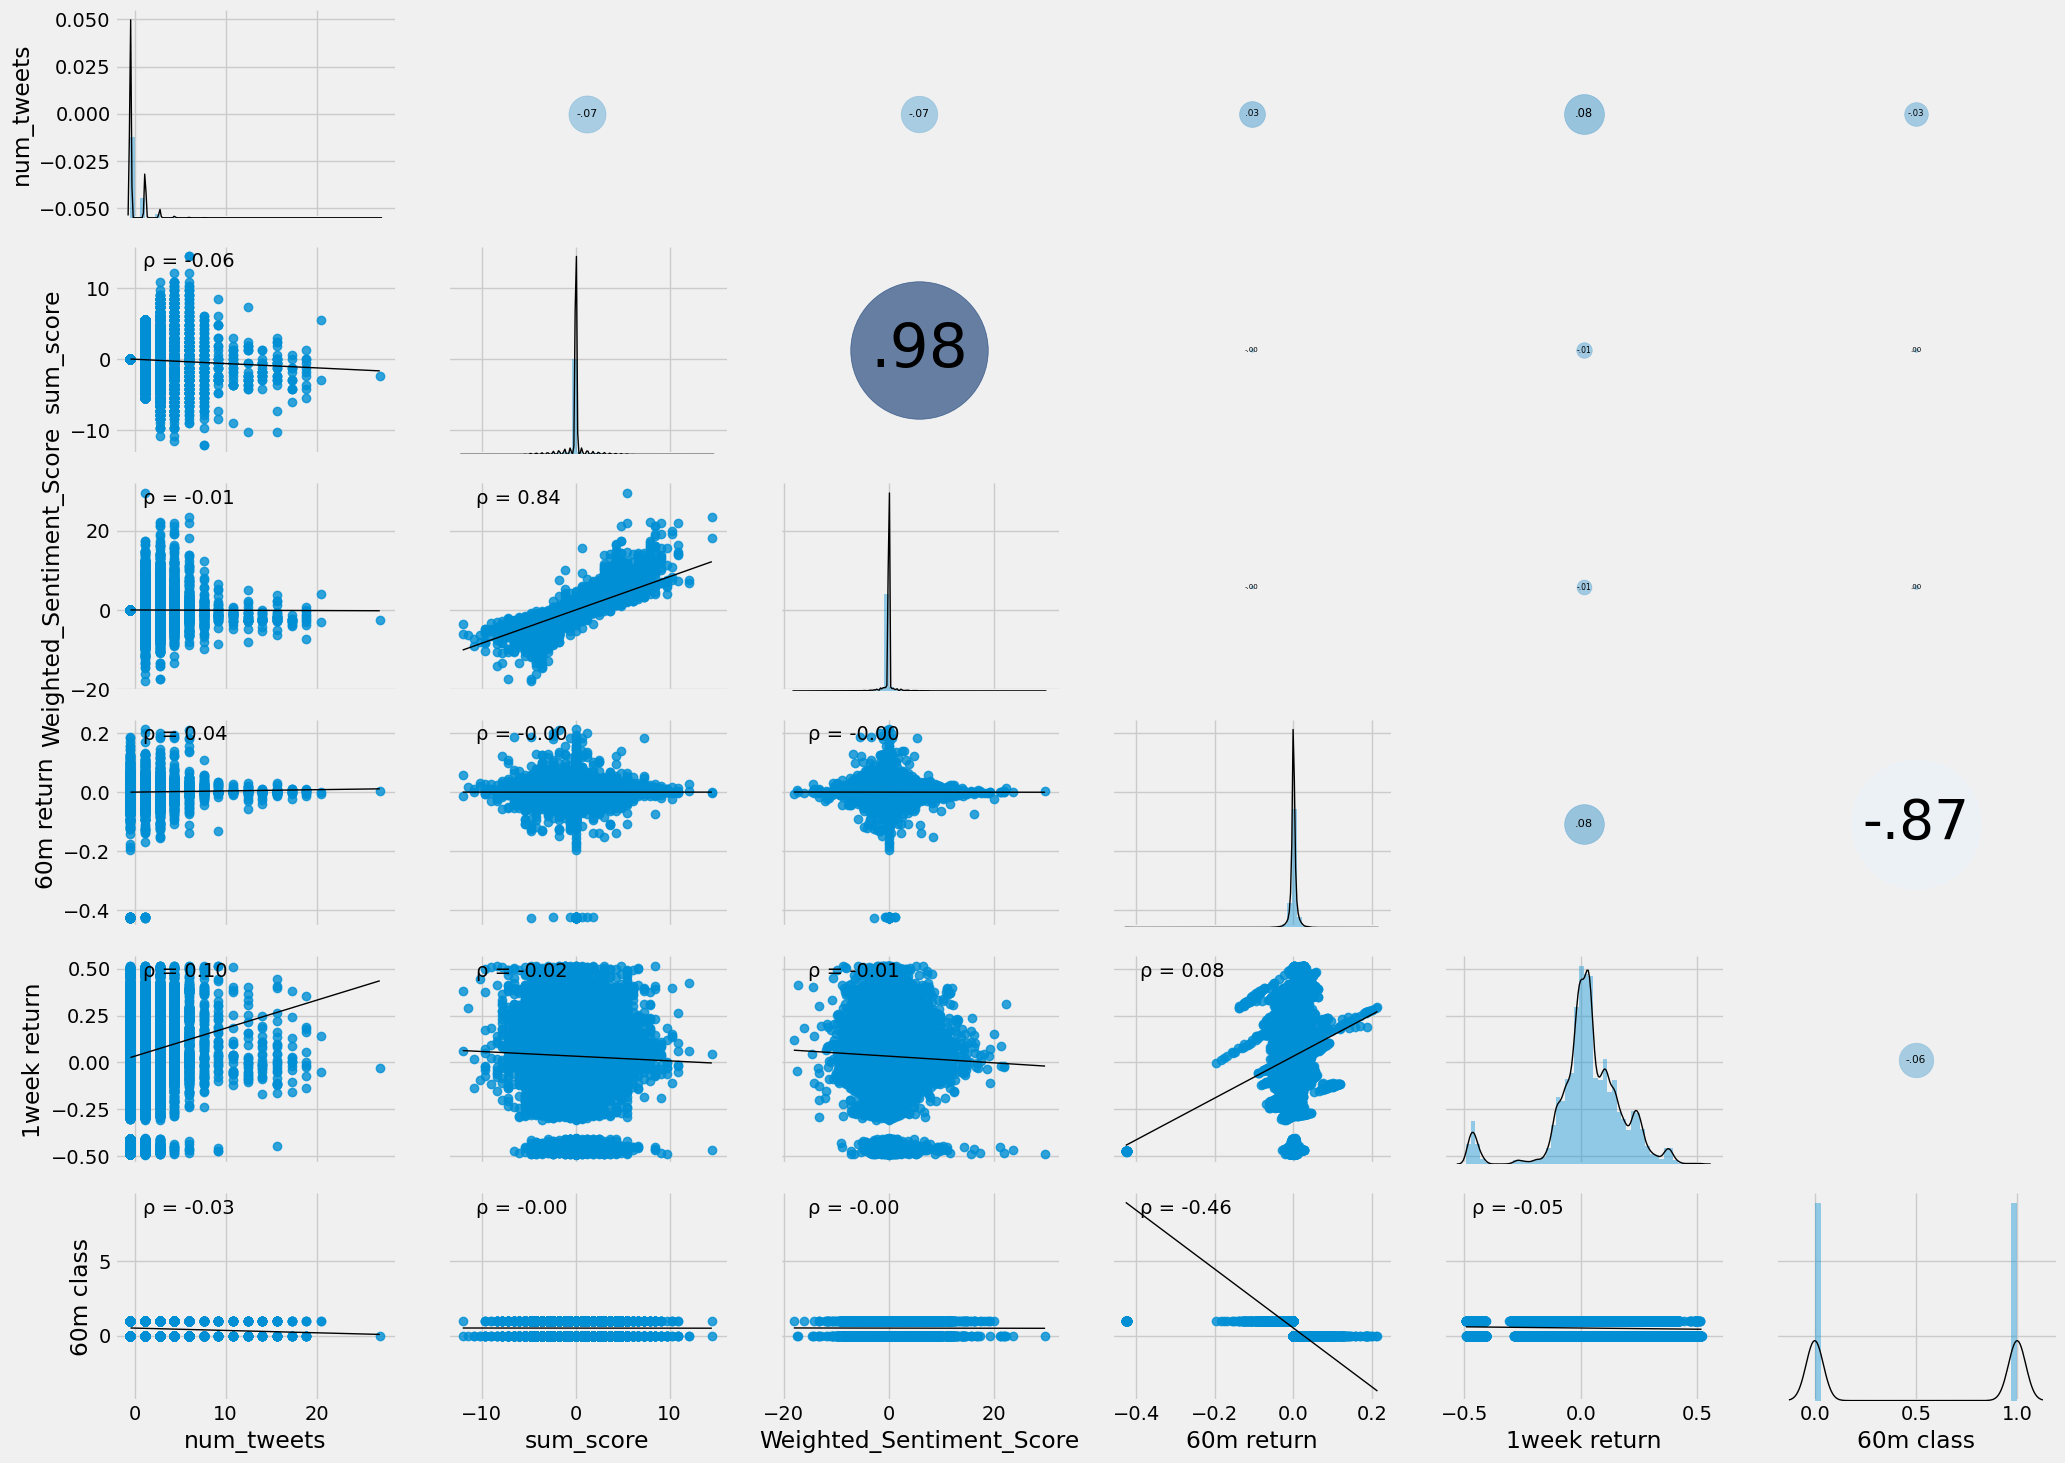

<Figure size 2000x2000 with 0 Axes>

In [63]:
from scipy.stats import pearsonr

def corrfunc(x,y, ax=None, **kws):
    """Plot the correlation coefficient in the top left hand corner of a plot."""
    r, _ = pearsonr(x, y)
    ax = ax or plt.gca()
    # Unicode for lowercase rho (ρ)
    rho = '\u03C1'
    ax.annotate(f'{rho} = {r:.2f}', xy=(.1, .9), xycoords=ax.transAxes)
    
def corrdot(*args, **kwargs):
    corr_r = args[0].corr(args[1], 'spearman')
    corr_text = f"{corr_r:2.2f}".replace("0.", ".")
    ax = plt.gca()
    ax.set_axis_off()
    marker_size = abs(corr_r) * 10000
    ax.scatter([.5], [.5], marker_size, [corr_r], alpha=0.6, cmap="Blues",
               vmin=-1, vmax=1, transform=ax.transAxes)
    font_size = abs(corr_r) * 40 + 5
    ax.annotate(corr_text, [.5, .5,],  xycoords="axes fraction",
                ha='center', va='center', fontsize=font_size)    
    
# g = sns.pairplot(stocks,palette=["Blues_d"])
g = sns.PairGrid(timeseries, aspect=1.4, diag_sharey=False)
g.map_lower(corrfunc)
g.map_lower(sns.regplot,  ci=False, line_kws={'color': 'Black','linewidth':1})
g.map_diag(sns.distplot, kde_kws={'color': 'Black','linewidth':1})
g.map_upper(corrdot)
plt.figure(figsize=(20, 20))
plt.show()